In [3]:
#SCISSORS Analysis: Plotting and tabulation
#2.25.24 PT Dolan, NIAID-NIH

In [ ]:
install.packages("Seurat")
install.packages("SeuratObject")

In [ ]:
suppressPackageStartupMessages(library(data.table))
suppressPackageStartupMessages(library(tidyverse))
suppressPackageStartupMessages(library(ggplot2))

In [ ]:
THEME=theme_classic()

In [ ]:
#EV71=fread("/data/lvd_qve/Lab_Spaces/PTD/notebooks/EVA71_TT_S4_CBC_SCISSORS.csv")    

In [ ]:
"/data/lvd_qve/Projects/PTD_StrandSpecificCounting_scRNAseq/CellRanger/final.metadata0.3.csv"

In [ ]:
CollectFiles<-function(files){
    allfiles=NULL
    for (i in files){ #for file in list...
        print(i)
        IF=fread(i,header = T) #read file. 
        #print(IF)
        IF$filename=i
        #IF=IF[-Neg.],fill=0,formula = CBC+filename+sample+datalabel+CBC_readcount+UMI_count+Neg_PosRatio+Rep_Index+ref_name~det_strand,value.var = "UMI_strand_count")
        IF=IF[,-c("Neg","Pos")]#removes the strand columns. 
        allfiles=rbindlist(list(allfiles,IF)) #concatenating the files.
        }
    return(unique(allfiles))
    }

fitSet<-function(Set){#given a input dataset...
    minimalSet=unique(dcast.data.table(Set[(UMI_count>100)],filename+ref_name+sample+CBC~det_strand,value.var = "UMI_strand_count",fill = 0,drop = T))

    plot(ggplot(minimalSet)+
         geom_point(show.legend = F,aes(col=paste(sample,filename),Pos,Neg),cex=0.2)+
         geom_smooth(method='glm',show.legend = F,aes(col=paste(sample,filename),Pos,Neg)))
    
    Fits=minimalSet[,   print(summary(glm(Neg~Pos))$coefficients[1:8]),# function applied across the data.table extract the slope
                             by=c("filename","ref_name","sample")]    # do this for each input file, sample, each reference.
    break
    Fits=minimalSet[,data.frame(
                        Ratio=summary(glm(Neg~Pos))$coefficients[2],  # function applied across the data.table extract the slope
                        Error=summary(glm(Neg~Pos))$coefficients[4]), # extract the error estimate on the slope 
                             by=c("filename","ref_name","sample")]    # do this for each input file, sample, each reference.
    return(Fits)
    }


In [ ]:
prefix="~/lab_share/Lab_Spaces/PTD/notebooks/"

FList=c("Mock_5h_S5_CBC_SCISSORS.csv",
#"CVB3_HH_S1_CBC_SCISSORS.csv",
"CVB3_TT_S2_CBC_SCISSORS.csv",
#"EVA71_HH_S3_CBC_SCISSORS.csv",
"EVA71_TT_S4_CBC_SCISSORS.csv",
'WT-Don+No-Acc_S1i_CBC_SCISSORS.csv')

FList=paste(prefix,FList,sep="")


[1] "~/lab_share/Lab_Spaces/PTD/notebooks/Mock_5h_S5_CBC_SCISSORS.csv"
[1] "~/lab_share/Lab_Spaces/PTD/notebooks/CVB3_TT_S2_CBC_SCISSORS.csv"
[1] "~/lab_share/Lab_Spaces/PTD/notebooks/EVA71_TT_S4_CBC_SCISSORS.csv"
[1] "~/lab_share/Lab_Spaces/PTD/notebooks/WT-Don+No-Acc_S1i_CBC_SCISSORS.csv"


`geom_smooth()` using formula = 'y ~ x'


[1] -1.835066e+01  1.971877e-01  2.904398e+00  2.954888e-03 -6.318231e+00
[6]  6.673272e+01  3.303129e-10  0.000000e+00
[1] -4.316019e+00  1.347435e-01  8.282448e+00  1.029193e-02 -5.211042e-01
[6]  1.309215e+01  6.045064e-01  4.331948e-18
[1]  60 NaN NaN NaN  NA  NA  NA  NA
[1] -1.665084e+01  7.499147e-02  1.186064e+00  6.953650e-04 -1.403874e+01
[6]  1.078448e+02  5.471933e-44  0.000000e+00
[1] -1.733730e+01  7.514497e-02  1.192656e+00  6.974648e-04 -1.453671e+01
[6]  1.077402e+02  5.656567e-47  0.000000e+00


ERROR: Error in fitSet(InputSet): no loop for break/next, jumping to top level


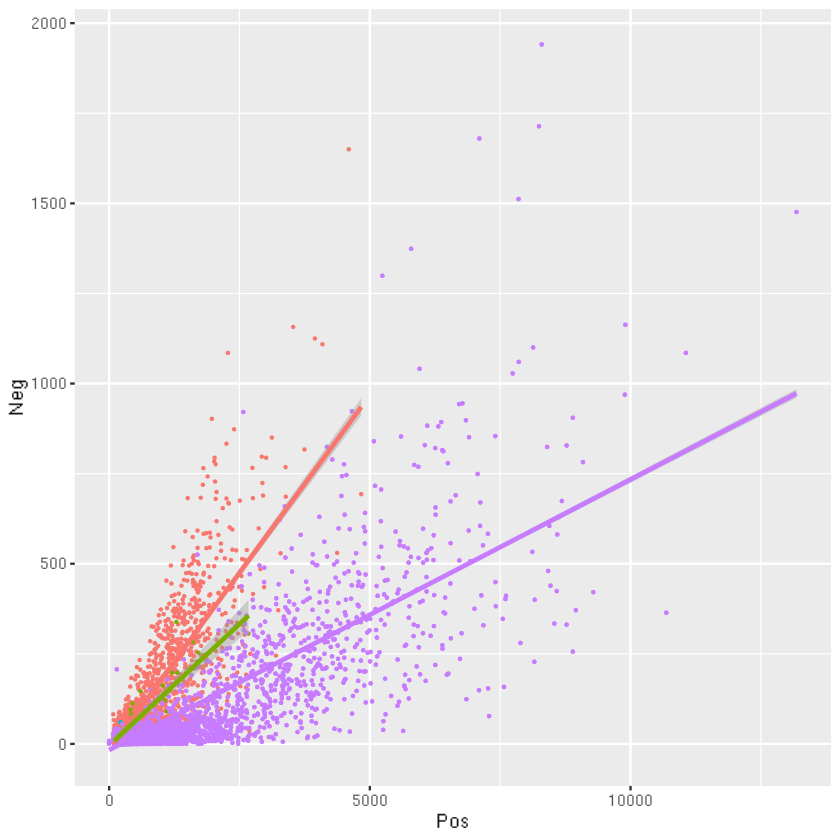

In [ ]:
InputSet=CollectFiles(FList)

Fits=fitSet(InputSet)

ggsave("Density.pdf",width=8,height=8,
    ggplot(InputSet[det_strand=="Neg"&ref_name!="RepliconNoInsert"])+
    theme_bw()+
    geom_histogram(binwidth=.1,aes(1/Neg_PosRatio,fill=sample),col="black",position='identity',alpha=0.4)+
    #geom_density(stat = 'count',bw=1,aes(1/Neg_PosRatio,fill=sample),col='black',position='identity',alpha=0.4)+
    scale_x_log10()+
    facet_grid(sample~.,scales = "free_y")+
    scale_fill_brewer(palette = "Paired")
)


`geom_smooth()` using formula = 'y ~ x'


[1] -1.835066e+01  1.971877e-01  2.904398e+00  2.954888e-03 -6.318231e+00
[6]  6.673272e+01  3.303129e-10  0.000000e+00
[1] -4.316019e+00  1.347435e-01  8.282448e+00  1.029193e-02 -5.211042e-01
[6]  1.309215e+01  6.045064e-01  4.331948e-18
[1]  60 NaN NaN NaN  NA  NA  NA  NA
[1] -1.665084e+01  7.499147e-02  1.186064e+00  6.953650e-04 -1.403874e+01
[6]  1.078448e+02  5.471933e-44  0.000000e+00
[1] -1.733730e+01  7.514497e-02  1.192656e+00  6.974648e-04 -1.453671e+01
[6]  1.077402e+02  5.656567e-47  0.000000e+00


ERROR: Error in fitSet(InputSet): no loop for break/next, jumping to top level


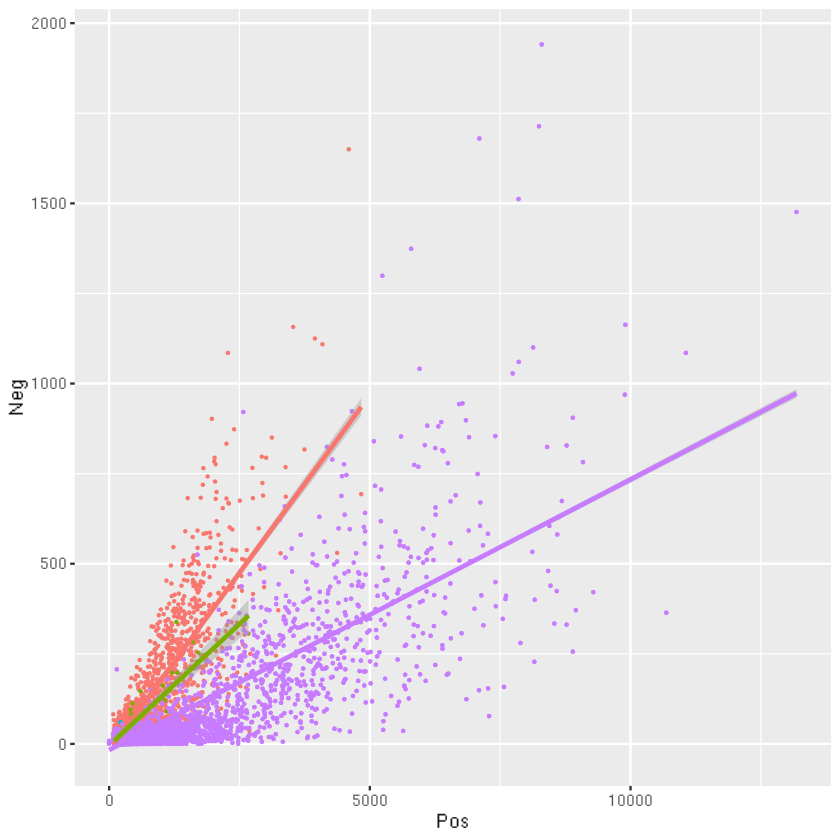

In [ ]:
fits=fitSet(InputSet)
ggsave(filename = "Ratios_3Virus.pdf",height = 4,width=10,
cowplot::plot_grid(align = "hv",
    ggplot(fits)+
theme_bw()+ylab("Negative Strands / Positive")+
scale_color_brewer(palette = "Paired")+
geom_pointrange(aes(x=factor(sample,levels=c('CVB3_TT_S2_CBC.csv','EVA71_TT_S4_CBC.csv','WT_IRES_GFP_S1_CBC.csv','Mock_5h_S5_CBC.csv')),col=sample,y=Ratio,ymax=(Ratio+Error),ymin=(Ratio-Error)))+ylim(0,NA),


ggplot(fits)+
theme_bw()+ylab("Positive Strands / Negative")+
scale_color_brewer(palette = "Paired")+
geom_pointrange(aes(x=factor(sample,levels=c('CVB3_TT_S2_CBC.csv','EVA71_TT_S4_CBC.csv','WT_IRES_GFP_S1_CBC.csv','Mock_5h_S5_CBC.csv')),col=sample,y=1/Ratio,ymax=1/(Ratio+Error),ymin=1/(Ratio-Error)))+ylim(0,NA)

))

In [ ]:
install.packages("SeuratObject")
library(Seurat)

Installing package into ‘/data/apps/software/spack/linux-rocky9-x86_64_v3/gcc-11.3.1/r-cairo-1.6-0-5d3ach7al2nfw47iphr7utknoctag3w7/rlib/R/library’
(as ‘lib’ is unspecified)

Warning message in install.packages("SeuratObject"):
“'lib = "/data/apps/software/spack/linux-rocky9-x86_64_v3/gcc-11.3.1/r-cairo-1.6-0-5d3ach7al2nfw47iphr7utknoctag3w7/rlib/R/library"' is not writable”


ERROR: Error in install.packages("SeuratObject"): unable to install packages


CBC,UMI_count,ref_name,sample,Neg,Pos
<chr>,<int>,<chr>,<chr>,<int>,<int>
AAACCACTCACACCAC,2,RepliconNoInsert,WT_IRES_GFP_S1_CBC.csv,0,2
AAACCGGAATTTTGCT,2,RepliconNoInsert,WT_IRES_GFP_S1_CBC.csv,2,0
AAACCTGAATTTTGCT,3,RepliconNoInsert,WT_IRES_GFP_S1_CBC.csv,2,2
AAACCTGAGACGACGT,4438,RepliconNoInsert,WT_IRES_GFP_S1_CBC.csv,184,4254
AAACCTGAGACGACGT,4438,eGFP,WT_IRES_GFP_S1_CBC.csv,184,4254
AAACCTGAGAGTGACC,99,RepliconNoInsert,WT_IRES_GFP_S1_CBC.csv,2,97


`geom_smooth()` using formula = 'y ~ x'


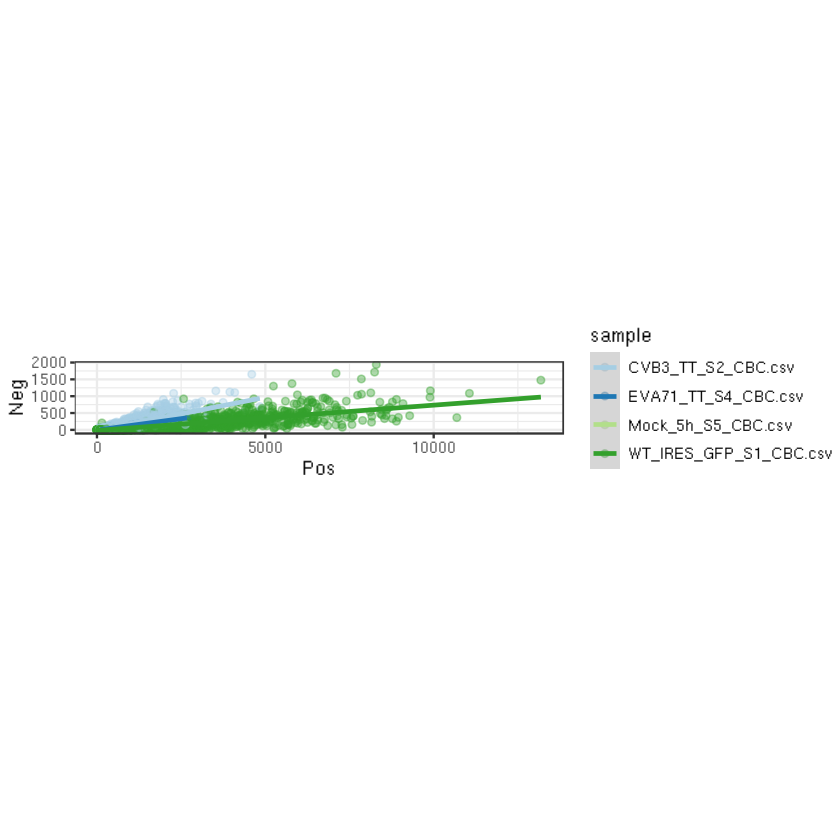

In [ ]:
reshapeInputSet=dcast.data.table(fill = 0,InputSet,value.var = "UMI_strand_count",CBC+UMI_count+ref_name+sample~det_strand)
head(reshapeInputSet)

#ggsave("FitsLines.pdf",width=10,height=6,
       
       ggplot(reshapeInputSet[(UMI_count>100)&(ref_name!="RepliconNoInsert")])+
       theme_bw()+
        geom_point(aes(Pos,Neg,col=sample),alpha=0.4)+
        geom_smooth(method='glm',aes(Pos,Neg,col=sample))+
        coord_fixed()+
        scale_color_brewer(palette = "Paired")
       
       
#)



In [ ]:
#SEURAT METADATA
#function for importing the UMAP coordinates
extractUMAP<-function(RDS){
    seuratData<-read_rds(RDS)
    print(seuratData)
    return(data.table(V1=rownames(seuratData@reductions$umap@cell.embeddings),seuratData@reductions$umap@cell.embeddings))
}

# read in the metadata csv 
CVBmd=fread("/hpcdata/lvd_qve/Projects/CM_kb/SCISSORS/CVB3_TT.csv")
EVA71md=fread("/hpcdata/lvd_qve/Projects/CM_kb/SCISSORS/EVA71_TT.csv")

#extracting the UMAP coordinates 
UMAPcvb=extractUMAP(RDS = "/hpcdata/lvd_qve/Projects/CM_kb/SCISSORS/CVB3_TT.rds")
UMAPev71=extractUMAP(RDS = "/hpcdata/lvd_qve/Projects/CM_kb/SCISSORS/EVA71_TT.rds")

#merge into a single object with coords and metadata. 
CVBsc<-merge.data.table(CVBmd,UMAPcvb,by="V1")
EV71sc<-merge.data.table(EVA71md,UMAPev71,by = "V1")

ERROR: Error: File '/hpcdata/lvd_qve/Projects/CM_kb/SCISSORS/CVB3_TT.csv' does not exist or is non-readable. getwd()=='/data/lvd_qve/Projects/PTD_StrandSpecificCounting_scRNAseq'


In [ ]:
#Merge single-cell with SCISSORS counts

CVBsc[,datalabel:="CVB3_TT"]
EV71sc[,datalabel:="EVA71_TT"]
CVBsc[,CBC:=tstrsplit(V1,"-")[1]]
EV71sc[,CBC:=tstrsplit(V1,"-")[1]]

scData=rbindlist(list(CVBsc,EV71sc))
head(scData)
head(InputSet)
mergedScissors=merge.data.table(scData,InputSet,by=c("CBC","datalabel"))

V1,orig.ident,nCount_RNA,nFeature_RNA,percent.mtribo,percent.mt,doublet_scores,predicted_doublets,S.Score,G2M.Score,Phase,old.ident,RNA_snn_res.0.35,seurat_clusters,UMAP_1,UMAP_2,datalabel,CBC
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>
AAACCTGTCCAAATGC-1,CVB3_TT,12273,3660,20.98916,2.9495641,0.11153119,FALSE,-0.16686294,0.33723307,G2M,CVB3_TT,0,0,3.0027240,3.56113777,CVB3_TT,AAACCTGTCCAAATGC
AAACGGGCACGGCGTT-1,CVB3_TT,16500,4531,18.76970,1.1878788,0.26562500,FALSE,0.09362969,-0.23836010,S,CVB3_TT,1,1,0.3935585,-0.53691116,CVB3_TT,AAACGGGCACGGCGTT
AAACGGGGTAGAGTGC-1,CVB3_TT,21980,4827,18.77616,0.5686988,0.04239238,FALSE,-0.16605865,0.25934488,G2M,CVB3_TT,2,2,-3.1663684,0.35444579,CVB3_TT,AAACGGGGTAGAGTGC
AAAGATGAGATATGCA-1,CVB3_TT,11693,3703,17.07859,1.2657145,0.14155251,FALSE,-0.02652000,-0.04843445,G1,CVB3_TT,0,0,4.5044826,0.54222217,CVB3_TT,AAAGATGAGATATGCA
AAAGATGAGGGTGTTG-1,CVB3_TT,9598,3110,26.81809,1.3961242,0.20842105,FALSE,-0.06600729,-0.19414493,G1,CVB3_TT,1,1,2.1043206,0.51959798,CVB3_TT,AAAGATGAGGGTGTTG
AAAGATGCAGGGTTAG-1,CVB3_TT,11302,3853,18.12953,2.0704300,0.13024911,FALSE,-0.24744351,-0.10572404,G1,CVB3_TT,1,1,2.2270337,0.09162733,CVB3_TT,AAAGATGCAGGGTTAG


V1,CBC,det_strand,sample,datalabel,CBC_readcount,UMI_count,UMI_strand_count,Neg_PosRatio,Rep_Index,ref_name,filename
<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<chr>,<chr>
1,CAAGGCCCATGGAATA,Pos,Mock_5h_S5_CBC.csv,Mock_5h,349,278,218,0.2739726,0.2158273,CVB3_RNA,Mock_5h_S5_CBC_SCISSORS.csv
3,CAAGGCCCATGGAATA,Neg,Mock_5h_S5_CBC.csv,Mock_5h,349,278,60,0.2739726,0.2158273,CVB3_RNA,Mock_5h_S5_CBC_SCISSORS.csv
0,GACGTTATCTTATCTG,Neg,CVB3_TT_S2_CBC.csv,CVB3_TT,2253,1778,546,0.4428224,0.3070866,CVB3_RNA,CVB3_TT_S2_CBC_SCISSORS.csv
4,GTGCAGCGTAGATTAG,Neg,CVB3_TT_S2_CBC.csv,CVB3_TT,2601,2037,300,0.1725129,0.1472031,CVB3_RNA,CVB3_TT_S2_CBC_SCISSORS.csv
5,GTAACGTTCCCTTGTG,Pos,CVB3_TT_S2_CBC.csv,CVB3_TT,1404,1110,991,0.1209677,0.1080108,CVB3_RNA,CVB3_TT_S2_CBC_SCISSORS.csv
6,GACTACATCGTGGGAA,Pos,CVB3_TT_S2_CBC.csv,CVB3_TT,4042,3178,2641,0.2036336,0.1692356,CVB3_RNA,CVB3_TT_S2_CBC_SCISSORS.csv


In [ ]:
pdf("UMAPS.pdf",width = 10,height=10)
cowplot::plot_grid(nrow=2,align = "hv",
ggplot(mergedScissors,aes(UMAP_1,UMAP_2))+
    theme_bw()+
    geom_point(data=EV71sc,aes(UMAP_1,UMAP_2),color="darkgrey",alpha=0.4,size=0.01)+
    geom_point(data=CVBsc,aes(UMAP_1,UMAP_2),color="darkgrey",alpha=0.4,size=0.01)+
    geom_point(aes(col=Rep_Index,size=UMI_count))+
    facet_grid(~datalabel)+
    scale_size_continuous(range = c(0.1,2))+
    scale_color_viridis_c(option = 3)+
    coord_fixed()
,
ggplot(mergedScissors,aes(UMAP_1,UMAP_2))+
    theme_bw()+
    geom_point(data=EV71sc,aes(UMAP_1,UMAP_2),color="darkgrey",alpha=0.4,size=0.01)+
    geom_point(data=CVBsc,aes(UMAP_1,UMAP_2),color="darkgrey",alpha=0.4,size=0.01)+
    geom_point(aes(fill=as.factor(seurat_clusters),size=UMI_count/nCount_RNA),pch=21)+
    facet_grid(~datalabel)+
    scale_fill_brewer(palette = "Set1")+
    scale_size_continuous(range = c(0.1,3))+
    coord_fixed()
                  )


dev.off()

png 
  2

In [ ]:
dev.off()

pdf 
  3

In [ ]:
#Compute and plot slopes per cluster

ggsave("Cluster_Rates.pdf",width=4
       ,
ggplot(mergedScissors[,fitSet(.SD),by=seurat_clusters])+
    geom_pointrange(aes(col=as.factor(seurat_clusters),x=seurat_clusters,y=Ratio,ymin=Ratio-Error, ymax=Ratio+Error))+
    facet_grid(sample~.)+
    theme_bw()+
    scale_color_brewer(palette = "Set1")+
    ylim(0,NA)
)

resSCISSORS=dcast.data.table(mergedScissors,CBC+UMI_count+seurat_clusters+sample~det_strand,value.var = "UMI_strand_count",drop = T)

ggsave("ClusterSlopes.pdf",width = 5,height=4,ggplot(resSCISSORS[UMI_count>100])+
    geom_point(size=0.4,aes(col=as.factor(seurat_clusters),x=Pos,y=Neg))+
    geom_smooth(method="glm",aes(col=as.factor(seurat_clusters),x=Pos,y=Neg))+
    scale_color_brewer(palette = "Set1")+
    theme_bw()+
    ylim(0,NA))

Saving 4 x 6.67 in image


                         filename
  1:  CVB3_TT_S2_CBC_SCISSORS.csv
  2:  CVB3_TT_S2_CBC_SCISSORS.csv
  3:  CVB3_TT_S2_CBC_SCISSORS.csv
  4:  CVB3_TT_S2_CBC_SCISSORS.csv
  5:  CVB3_TT_S2_CBC_SCISSORS.csv
 ---                             
470: EVA71_TT_S4_CBC_SCISSORS.csv
471: EVA71_TT_S4_CBC_SCISSORS.csv
472: EVA71_TT_S4_CBC_SCISSORS.csv
473: EVA71_TT_S4_CBC_SCISSORS.csv
474: EVA71_TT_S4_CBC_SCISSORS.csv
                                                       ref_name
  1:                                                   CVB3_RNA
  2:                                                   CVB3_RNA
  3:                                                   CVB3_RNA
  4:                                                   CVB3_RNA
  5:                                                   CVB3_RNA
 ---                                                           
470: pUC19-EV71-TW_Tainan_1998_4643_BsmBI-and-BsaI-free-Deleted
471: pUC19-EV71-TW_Tainan_1998_4643_BsmBI-and-BsaI-free-Deleted
472: pUC19-EV71-

Warning message:
“Removed 2 rows containing missing values (`geom_pointrange()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 1 rows containing non-finite values (`stat_smooth()`).”
Warning message:
“Removed 1 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 2 rows containing missing values (`geom_smooth()`).”


V1,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<chr>
ZFAS1,1.076257e-76,0.8089793,0.985,0.912,2.024440e-72,0,ZFAS1
TAF1D,3.904106e-76,0.8024456,0.978,0.861,7.343624e-72,0,TAF1D
MYC,1.295921e-75,0.9912169,0.992,0.930,2.437627e-71,0,MYC
ID1,9.518002e-67,1.0371772,0.975,0.921,1.790336e-62,0,ID1
ID3,2.084826e-61,0.8366044,0.995,0.986,3.921557e-57,0,ID3
SNHG15,1.405245e-60,0.7267281,0.925,0.711,2.643265e-56,0,SNHG15
SNHG1,3.637710e-58,0.7675473,0.847,0.553,6.842533e-54,0,SNHG1
GAS5,6.533799e-49,0.5884843,0.955,0.862,1.229007e-44,0,GAS5
EIF4A2,7.709839e-48,0.6275937,0.784,0.531,1.450221e-43,0,EIF4A2


Warning message:
“ggrepel: 36 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


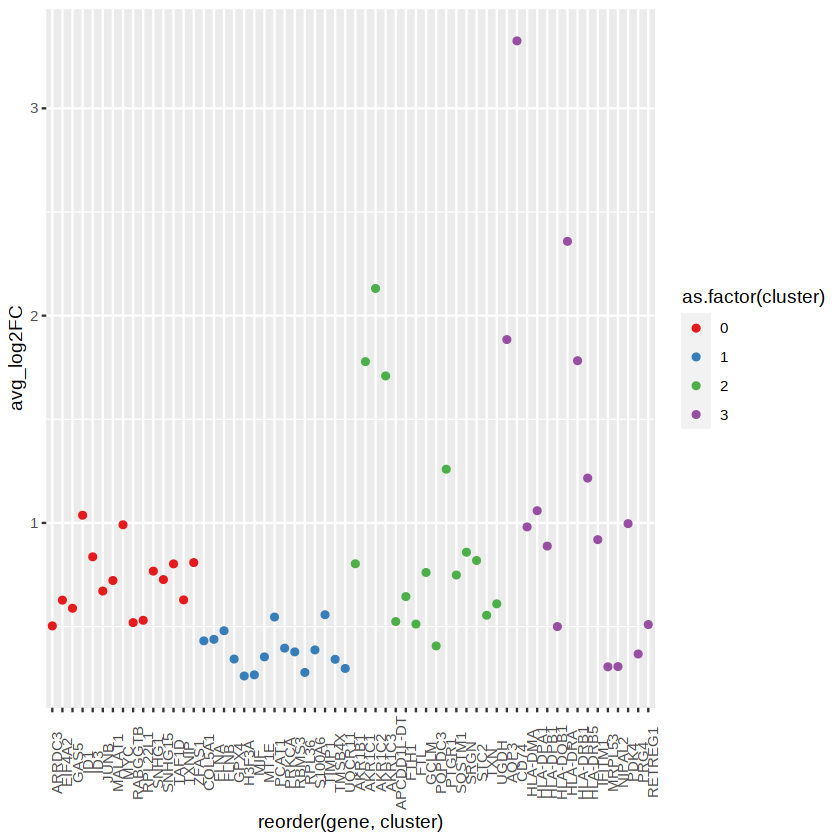

In [ ]:
#markers

CVBmarkers="/hpcdata/lvd_qve/Projects/CM_kb/SCISSORS/CVB3_TT.markers_Pos.csv"
CVBmarkers=fread(CVBmarkers)
CVBmarkers
ggplot(CVBmarkers[,.SD[rank(p_val_adj)][1:15,],by=cluster])+
    geom_point(aes(col=as.factor(cluster),reorder(gene,cluster),avg_log2FC))+
    scale_color_brewer(palette="Set1")+theme(axis.text.x = element_text(angle = 90))

ggsave(width=6,height=4,"CVB_markers.pdf",
ggplot(CVBmarkers[,.SD[rank(p_val_adj)][1:15,],by=cluster])+
    geom_point(aes(col=as.factor(cluster),avg_log2FC,-log10(p_val_adj)))+
    scale_color_brewer(palette="Set1")+
    ggrepel::geom_text_repel(aes(label=gene,col=as.factor(cluster),avg_log2FC,-log10(p_val_adj)))+
    ggtitle("Distinguishing Genes")+theme_bw()+ylab("-log10(Adj. p-value)")+xlab("Fold Enrichment"))

In [ ]:
#"Donor" and "Acceptor" Genotype Pairs

DonAccPairs=
c('No-Don+C109S-Acc_S2_CBC_SCISSORS.csv',
'No-Don+D177A-Acc_S4_CBC_SCISSORS.csv',
'No-Don+dIRES-Acc_S2_CBC_SCISSORS.csv',
'No-Don+dIRESGAA-Acc_S5_CBC_SCISSORS.csv',
#'No-Don+GAA-Acc_S3_CBC_SCISSORS.csv',
'No-Don+GAA-Acc_S4_CBC_SCISSORS.csv',
'No-Don+Y88P-Acc_S3_CBC_SCISSORS.csv',
'WT-Don+C109S-Acc_S5_CBC_SCISSORS.csv',
'WT-Don+D177A-Acc_S7_CBC_SCISSORS.csv',
'WT-Don+dIRES-Acc_S3_CBC_SCISSORS.csv',
#'WT-Don+GAA-Acc_S2_CBC_SCISSORS.csv',
'WT-Don+GAA-Acc_S6_CBC_SCISSORS.csv',
'WT-Don+No-Acc_S1_CBC_SCISSORS.csv',
'WT-Don+No-Acc_S1i_CBC_SCISSORS.csv',
'WT-Don+Y88P-Acc_S6_CBC_SCISSORS.csv')

PVList=CollectFiles(DonAccPairs)
PVList[,Comb:=tstrsplit(filename,split="_S")[1]]
PVList[,Donor:=tstrsplit(Comb,split="\\+")[1]]
PVList[,Acceptor:=tstrsplit(Comb,split="\\+")[2]]
print(PVList)
PVfit=fitSet(PVList)
PVfit


[1] "No-Don+C109S-Acc_S2_CBC_SCISSORS.csv"
[1] "No-Don+D177A-Acc_S4_CBC_SCISSORS.csv"
[1] "No-Don+dIRES-Acc_S2_CBC_SCISSORS.csv"
[1] "No-Don+dIRESGAA-Acc_S5_CBC_SCISSORS.csv"
[1] "No-Don+GAA-Acc_S4_CBC_SCISSORS.csv"
[1] "No-Don+Y88P-Acc_S3_CBC_SCISSORS.csv"
[1] "WT-Don+C109S-Acc_S5_CBC_SCISSORS.csv"
[1] "WT-Don+D177A-Acc_S7_CBC_SCISSORS.csv"
[1] "WT-Don+dIRES-Acc_S3_CBC_SCISSORS.csv"
[1] "WT-Don+GAA-Acc_S6_CBC_SCISSORS.csv"
[1] "WT-Don+No-Acc_S1_CBC_SCISSORS.csv"
[1] "WT-Don+No-Acc_S1i_CBC_SCISSORS.csv"
[1] "WT-Don+Y88P-Acc_S6_CBC_SCISSORS.csv"
             V1              CBC det_strand                     sample
     1:      16 GTTTCTACACCCATTC        Pos       RFP_C109S_S2_CBC.csv
     2:      23 ATGCGATGTATGAATG        Pos       RFP_C109S_S2_CBC.csv
     3:      25 TGAGCATCATCAGTCA        Pos       RFP_C109S_S2_CBC.csv
     4:      32 CTAGTGACAAGTCTGT        Pos       RFP_C109S_S2_CBC.csv
     5:      33 GACCTGGAGTCAATAG        Pos       RFP_C109S_S2_CBC.csv
    ---                

filename,ref_name,sample,Ratio,Error
<chr>,<chr>,<chr>,<dbl>,<dbl>
No-Don+C109S-Acc_S2_CBC_SCISSORS.csv,RepliconNoInsert,RFP_C109S_S2_CBC.csv,0.007512690,0.0001057668
No-Don+C109S-Acc_S2_CBC_SCISSORS.csv,eGFP,RFP_C109S_S2_CBC.csv,NaN,NaN
No-Don+C109S-Acc_S2_CBC_SCISSORS.csv,mRuby3,RFP_C109S_S2_CBC.csv,0.007215676,0.0001077498
No-Don+D177A-Acc_S4_CBC_SCISSORS.csv,RepliconNoInsert,RFP_D177A_S4_CBC.csv,0.007606343,0.0002105395
No-Don+D177A-Acc_S4_CBC_SCISSORS.csv,mRuby3,RFP_D177A_S4_CBC.csv,0.007038588,0.0002182491
No-Don+GAA-Acc_S4_CBC_SCISSORS.csv,RepliconNoInsert,WT_IRES_mRuby3_MutPol_S4_CBC.csv,0.012326411,0.0003820931
No-Don+GAA-Acc_S4_CBC_SCISSORS.csv,eGFP,WT_IRES_mRuby3_MutPol_S4_CBC.csv,-0.008955594,0.0341851030
No-Don+GAA-Acc_S4_CBC_SCISSORS.csv,mRuby3,WT_IRES_mRuby3_MutPol_S4_CBC.csv,0.012013588,0.0003995967
No-Don+Y88P-Acc_S3_CBC_SCISSORS.csv,RepliconNoInsert,RFP_488P_S3_CBC.csv,0.016087169,0.0002827120


Warning message:
“Removed 1 rows containing missing values (`geom_point()`).”
Warning message:
“Removed 1 row containing missing values (`geom_line()`).”


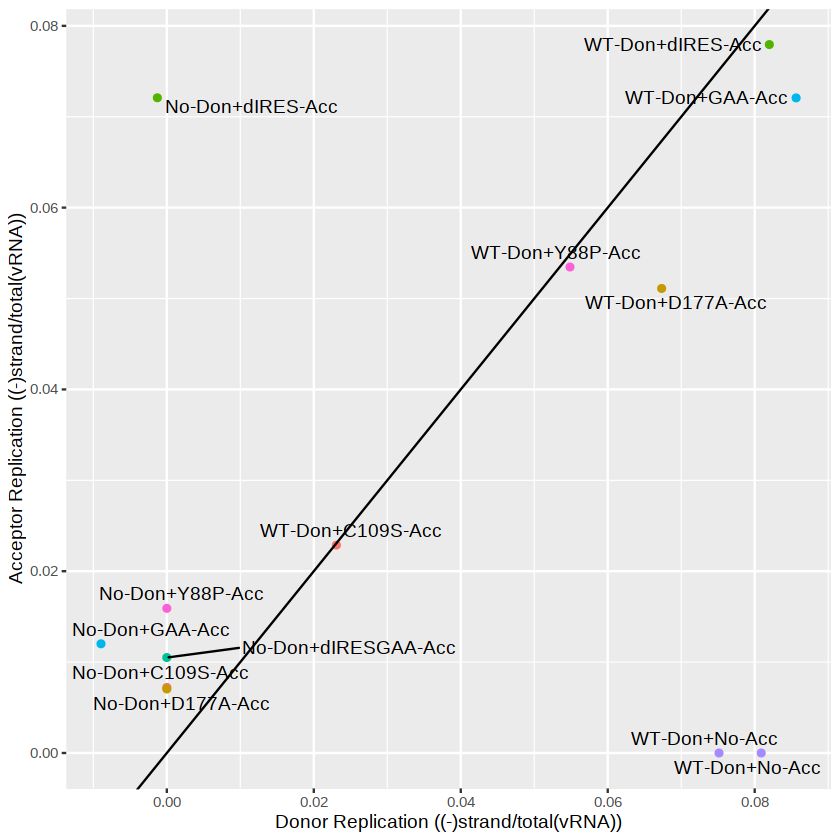

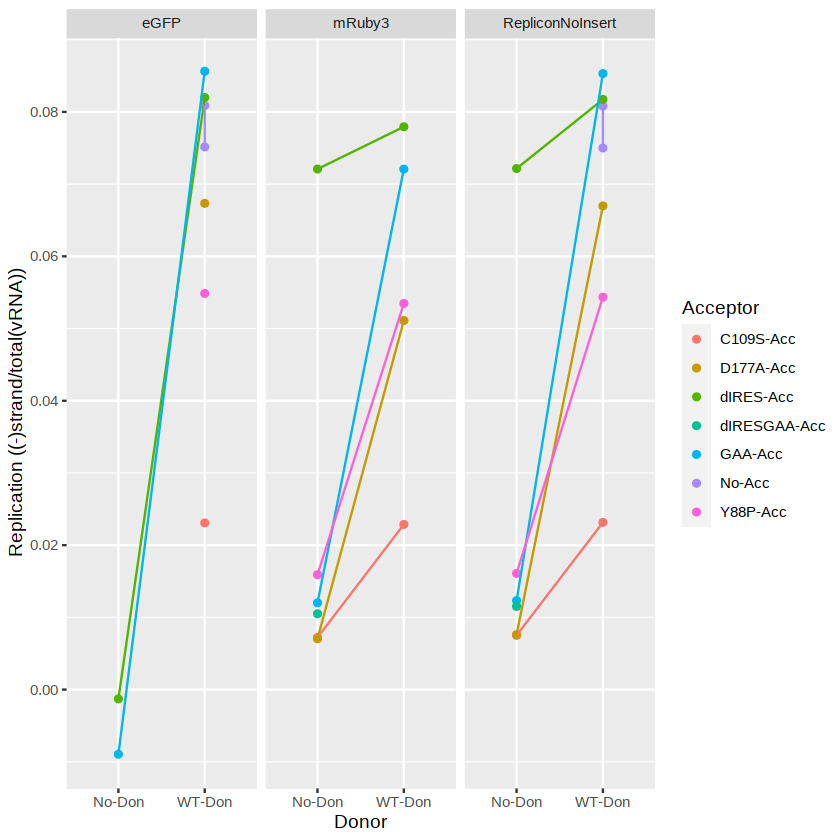

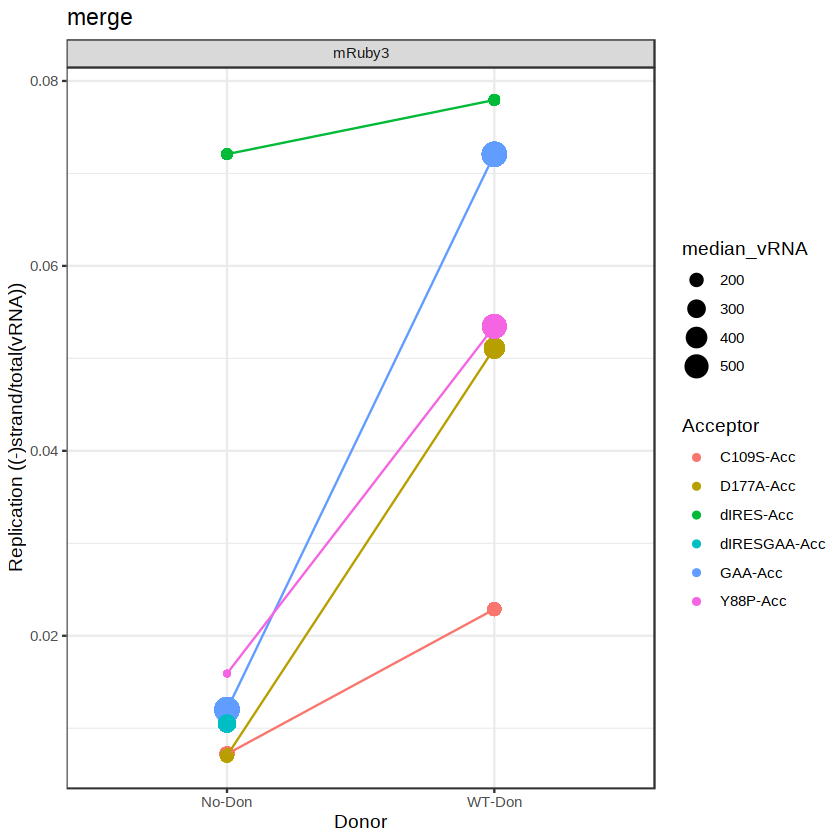

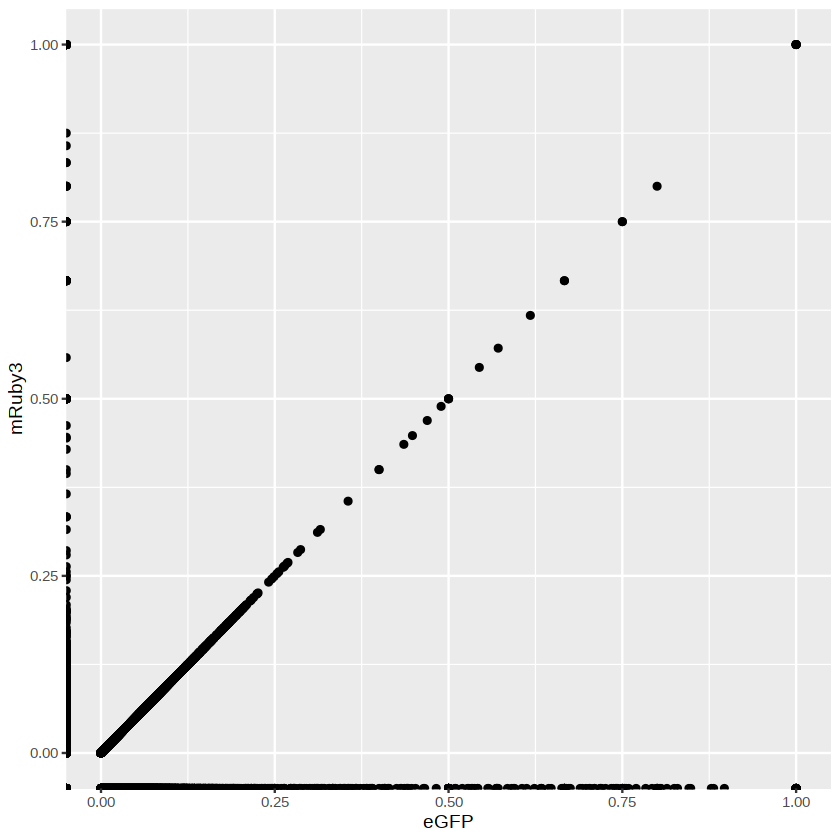

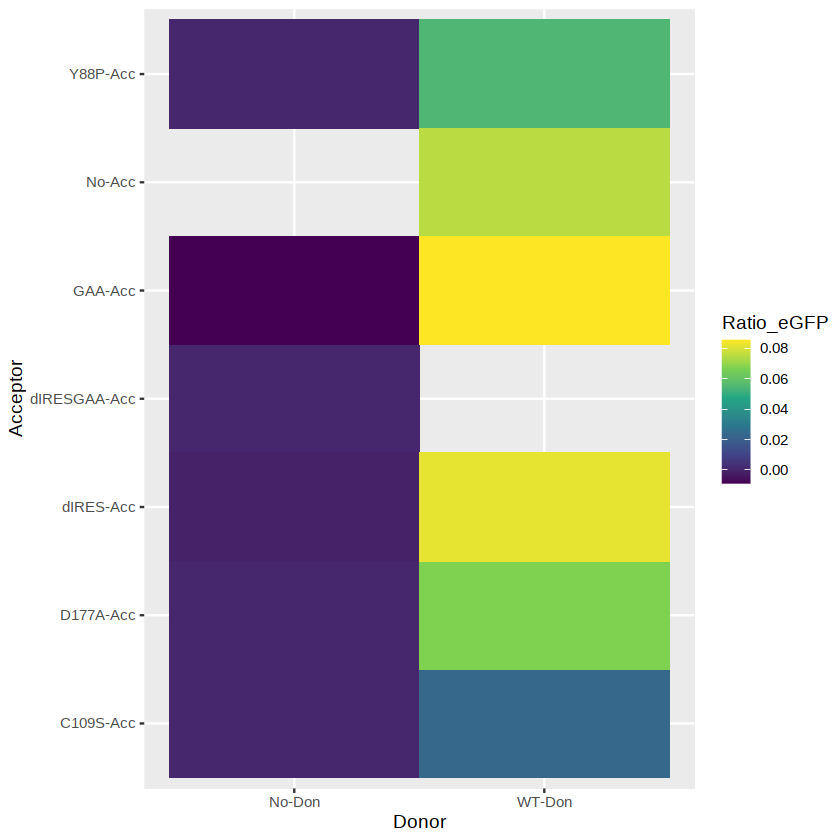

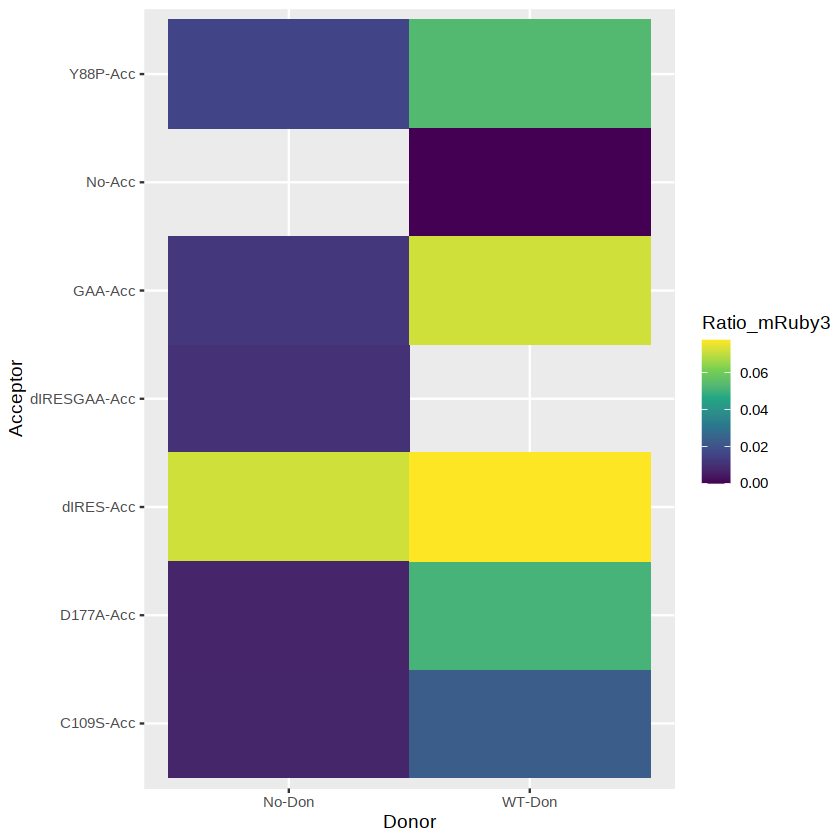

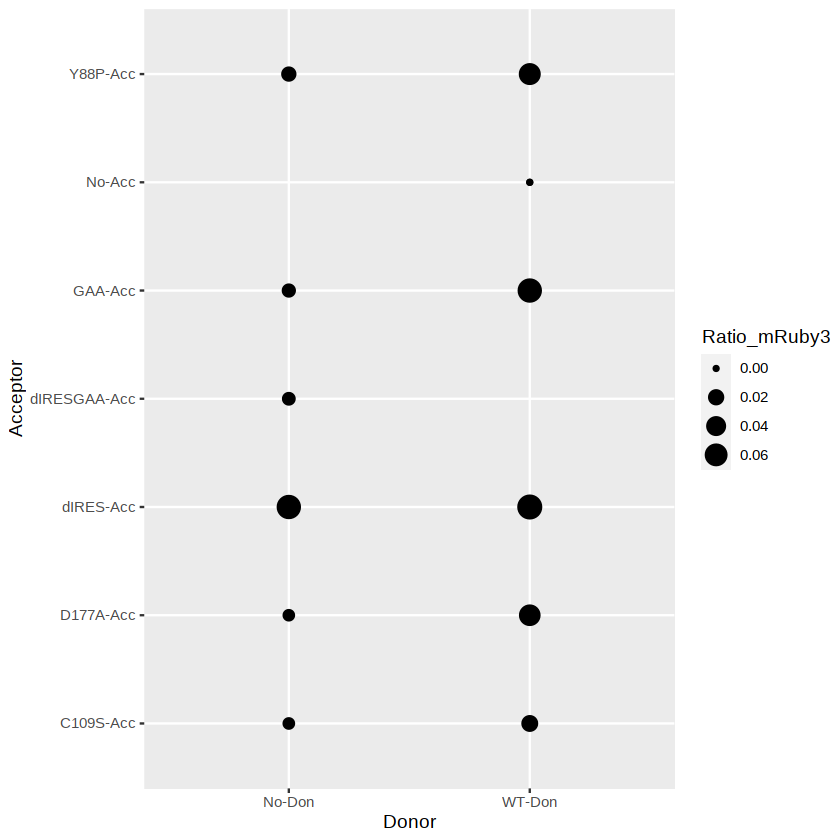

In [ ]:
PVfit[,Comb:=tstrsplit(filename,split="_S")[1]]
PVfit[,Donor:=tstrsplit(Comb,split="\\+")[1]]
PVfit[,Acceptor:=tstrsplit(Comb,split="\\+")[2]]

mPV=merge.data.table(PVList,PVfit,by = c("filename","ref_name","Donor","Acceptor","Comb","sample"))

cast_fits<-dcast.data.table(PVfit,sample+filename+Comb+Donor+Acceptor~ref_name,value.var = c("Ratio","Error"))
cast_fits[is.na(cast_fits)]=0

ggplot(cast_fits)+
    geom_point(show.legend = F,aes(col=Acceptor,Ratio_eGFP,Ratio_mRuby3))+
    ggrepel::geom_text_repel(aes(Ratio_eGFP,Ratio_mRuby3,label=Comb))+
    geom_abline(slope=1)+
    xlab("Donor Replication ((-)strand/total(vRNA))")+
    ylab("Acceptor Replication ((-)strand/total(vRNA))")

ggplot(PVfit)+
    geom_point(aes(col=Acceptor,Donor,Ratio))+
    geom_line(show.legend = F,aes(col=Acceptor,Donor,Ratio,group=Acceptor))+
    ylab("Replication ((-)strand/total(vRNA))")+facet_wrap(~ref_name)

mPV[,median_vRNA:=median(UMI_count+1),by=c("Donor","Acceptor","ref_name")]

ggplot(mPV[ref_name=="mRuby3"])+ggtitle("merge")+
    geom_point(aes(col=Acceptor,Donor,Ratio,size=median_vRNA))+
    geom_line(show.legend = F,aes(col=Acceptor,Donor,Ratio,group=Acceptor))+
    ylab("Replication ((-)strand/total(vRNA))")+
    theme_bw()+
    facet_wrap(~ref_name)

ggplot(dcast.data.table(PVList,CBC+sample+filename~ref_name,value.var = "Rep_Index",drop = T,fun.aggregate = max))+
    geom_point(aes(eGFP,mRuby3))

ggplot(cast_fits)+
    geom_tile(aes(Donor,Acceptor,fill=Ratio_eGFP))+scale_fill_viridis_c()

ggplot(cast_fits)+
    geom_tile(aes(Donor,Acceptor,fill=Ratio_mRuby3))+scale_fill_viridis_c()

ggplot(cast_fits)+
    geom_point(aes(Donor,Acceptor,size=Ratio_mRuby3))+scale_fill_viridis_c()
#    xlab("+/- Ratio - Donor")+ylab("+/- Ratio - Acceptor")+
#    geom_linerange(aes(col=filename,y=Ratio_mRuby3, xmin=Ratio_eGFP-Error_eGFP,xmax=Ratio_eGFP+Error_eGFP))+
#    geom_linerange(aes(col=filename,x=Ratio_eGFP, ymin=Ratio_mRuby3-Error_mRuby3,ymax=Ratio_mRuby3+Error_mRuby3))

In [ ]:
ggsave(width=10,height=6,filename =  "PVReplicon_Muts_geneticInteractions.pdf",
cowplot::plot_grid(align = "hv",
        
ggplot(unique(mPV[ref_name=="mRuby3",c("Acceptor","Donor","Ratio","Error","median_vRNA","ref_name")]))+
    ggtitle("Rescue of Mutant Replication")+
    geom_point(alpha=0.6,aes(col=Acceptor,Donor,Ratio,size=median_vRNA))+
    geom_linerange(show.legend = F,aes(col=Acceptor,Donor,Ratio,ymin=Ratio-Error,ymax=Ratio+Error))+
    geom_line(show.legend = F,aes(col=Acceptor,Donor,Ratio,group=Acceptor))+
    ylim(0,0.10)+
    ylab("Replication ((-)strand/total(vRNA))")+
    theme_bw()+
    theme(axis.text.x = element_text(angle=90))+
    facet_wrap(~ref_name)+
    scale_color_brewer(palette="Dark2"),

ggplot(unique(mPV[Donor=="WT-Don"&ref_name=="eGFP",c("Comb","Acceptor","Donor","Ratio","Error","median_vRNA","ref_name")]))+
    ggtitle("Effect of Mutant on co-infecting WT Replication")+
    theme_bw()+
    geom_point(alpha=0.6,aes(col=Acceptor,reorder(Comb,-Ratio,mean),y=Ratio,size=median_vRNA))+
    geom_linerange(show.legend = F,aes(col=Acceptor,reorder(Comb,-Ratio,mean),ymin=Ratio-Error,ymax=Ratio+Error))+
    ylab("Replication ((-)strand/total(vRNA))")+
    ylim(0,0.10)+
    theme(axis.text.x = element_text(angle=90))+
    facet_wrap(Donor~ref_name)+
    scale_color_brewer(palette = "Dark2")+
    scale_size("vRNA Content")
,ncol=2))

In [ ]:
ggplot(mPV[Donor=="WT-Don"&ref_name=="eGFP"])+
    ggtitle("Effect of Mutant on co-infecting WT Replication")+
    theme_bw()+
    geom_point(aes(col=Acceptor,reorder(Comb,-Ratio,mean),y=Ratio,size=median_vRNA))+
    geom_linerange(show.legend = F,aes(col=Acceptor,reorder(Comb,-Ratio,mean),ymin=Ratio-Error,ymax=Ratio+Error))+
    ylab("Replication ((-)strand/total(vRNA))")+
    coord_cartesian(0,0.10)+
    theme(axis.text.x = element_text(angle=90))+
    facet_wrap(Donor~ref_name)+
    scale_color_brewer(palette = "Dark2")


ERROR while rich displaying an object: Error in if (all(is.finite(continuous_range_coord)) && diff(continuous_range_coord) < : missing value where TRUE/FALSE needed

Traceback:
1. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
2. tryCatchList(expr, classes, parentenv, handlers)
3. tryCatchOne(expr, names, parentenv, handlers[[1L]])
4. doTryCatch(return(expr), name, parentenv, handler)
5. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler)
6. repr::mime2r

In [ ]:
dcast.data.table(PVList,CBC+sample+filename+ref_name~ref_name,value.var = "Rep_Index",drop = T,fun.aggregate = median)

CBC,sample,filename,ref_name,RepliconNoInsert,eGFP,mRuby3
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
AAACCACTCACACCAC,Del_IRES_mRuby3_S2_CBC.csv,No-Don+dIRES-Acc_S2_CBC_SCISSORS.csv,RepliconNoInsert,0.00000000,NA,NA
AAACCACTCACACCAC,WT_IRES_GFP_Del_IRES_mRuby3_S3_CBC.csv,WT-Don+dIRES-Acc_S3_CBC_SCISSORS.csv,RepliconNoInsert,0.00000000,NA,NA
AAACCACTCACACCAC,WT_IRES_GFP_S1_CBC.csv,WT-Don+No-Acc_S1i_CBC_SCISSORS.csv,RepliconNoInsert,0.00000000,NA,NA
AAACCACTCACACCAC,WT_IRES_mRuby3_MutPol_WT_IRES_GFP_S6_CBC.csv,WT-Don+GAA-Acc_S6_CBC_SCISSORS.csv,RepliconNoInsert,0.00000000,NA,NA
AAACCGGAATTTTGCT,WT_IRES_GFP_S1_CBC.csv,WT-Don+No-Acc_S1i_CBC_SCISSORS.csv,RepliconNoInsert,1.00000000,NA,NA
AAACCTGAATTTTGCT,WT_GFP_RFP_488P_S6_CBC.csv,WT-Don+Y88P-Acc_S6_CBC_SCISSORS.csv,RepliconNoInsert,0.50000000,NA,NA
AAACCTGAATTTTGCT,WT_IRES_GFP_Del_IRES_mRuby3_S3_CBC.csv,WT-Don+dIRES-Acc_S3_CBC_SCISSORS.csv,RepliconNoInsert,0.33333333,NA,NA
AAACCTGAATTTTGCT,WT_IRES_GFP_S1_CBC.csv,WT-Don+No-Acc_S1i_CBC_SCISSORS.csv,RepliconNoInsert,0.50000000,NA,NA
AAACCTGAGAAACCAT,WT_IRES_mRuby3_MutPol_S4_CBC.csv,No-Don+GAA-Acc_S4_CBC_SCISSORS.csv,RepliconNoInsert,0.03350254,NA,NA


In [ ]:
PVfit=fitSet(PVList)

                                    filename         ref_name
     1: No-Don+C109S-Acc_S2_CBC_SCISSORS.csv RepliconNoInsert
     2: No-Don+C109S-Acc_S2_CBC_SCISSORS.csv RepliconNoInsert
     3: No-Don+C109S-Acc_S2_CBC_SCISSORS.csv RepliconNoInsert
     4: No-Don+C109S-Acc_S2_CBC_SCISSORS.csv RepliconNoInsert
     5: No-Don+C109S-Acc_S2_CBC_SCISSORS.csv RepliconNoInsert
    ---                                                      
161322: WT-Don+dIRES-Acc_S3_CBC_SCISSORS.csv           mRuby3
161323: WT-Don+dIRES-Acc_S3_CBC_SCISSORS.csv           mRuby3
161324: WT-Don+dIRES-Acc_S3_CBC_SCISSORS.csv           mRuby3
161325: WT-Don+dIRES-Acc_S3_CBC_SCISSORS.csv           mRuby3
161326: WT-Don+dIRES-Acc_S3_CBC_SCISSORS.csv           mRuby3
                                        sample              CBC Neg  Pos
     1:                   RFP_C109S_S2_CBC.csv AAACCTGAGAGGTTGC   0  240
     2:                   RFP_C109S_S2_CBC.csv AAACCTGAGAGTAAGG   0  240
     3:                   RFP_C109S_S

In [ ]:
MergedData=merge.data.table(cast_fits,PVList,by="sample")

ggplot(unique(MergedData[,c("Donor","Acceptor","Ratio_eGFP","Ratio_mRuby3")]))+
    geom_abline(slope = 1)+
    geom_point(show.legend = F,aes(col=paste(Donor,Acceptor),1/Ratio_eGFP,1/Ratio_mRuby3))+

    geom_linerange(show.legend = F,aes(col=paste(Donor,Acceptor),y = 1/Ratio_mRuby3, xmin=1/(Ratio_eGFP+Error_eGFP),xmax=1/(Ratio_eGFP-Error_eGFP)))+
    geom_linerange(show.legend = F,aes(col=paste(Donor,Acceptor),x = 1/Ratio_eGFP,   ymin=1/(Ratio_mRuby3+Error_mRuby3),ymax=1/(Ratio_mRuby3-Error_mRuby3)))+
    ggrepel::geom_text_repel(cex=4,aes(label=paste(Donor,Acceptor),  1/Ratio_eGFP, 1/Ratio_mRuby3))+
    coord_fixed(xlim = c(0,NA))

ggplot(unique(MergedData[,c("Donor","Acceptor","Ratio_eGFP","Ratio_mRuby3")]))+
    geom_point(show.legend = F,aes(col=paste(Donor,Acceptor),reorder(paste(Donor,Acceptor),1/Ratio_eGFP),1/Ratio_eGFP))+
    theme(axis.text.x = element_text(angle=90))#+

ggplot(unique(MergedData[,c("Donor","Acceptor","Ratio_eGFP","Ratio_mRuby3")]))+
    geom_point(show.legend = F,aes(col=paste(Donor,Acceptor),reorder(paste(Donor,Acceptor),1/Ratio_mRuby3),1/Ratio_mRuby3))+
    theme(axis.text.x = element_text(angle=90))

#ggrepel::geom_text_repel(nudge_x = 3,cex=3,aes(label=paste(Donor,Acceptor),Ratio_eGFP,Ratio_mRuby3))+


ERROR: Error in `[.data.table`(MergedData, , c("Donor", "Acceptor", "Ratio_eGFP", : column(s) not found: Donor, Acceptor


In [ ]:
ggplot(unique(MergedData[,c("Donor","Acceptor","Ratio_eGFP","Ratio_mRuby3")]))+
    geom_histogram(aes(Ratio_eGFP),fill='green')+
    geom_histogram(aes(Ratio_mRuby3),fill='red')+scale_x_log10()

In [ ]:
ggplot(PVList)+
    geom_point(aes(CBC_readcount,Neg/Pos))+facet_grid(~filename)

In [ ]:
    ggplot(allDonAcc[Pos>0&Neg>0])+
        geom_point(size=0.2,aes(Pos,Neg,col=filename))+
        geom_smooth(method="glm",aes(Pos,Neg,col=filename))

In [ ]:
PVm<-merge.data.frame(allDonAcc,PVFits,by="filename")
PVm<-data.table(PVm)


In [ ]:
PVm[,Comb:=tstrsplit(filename,split="_S")[1]]
PVm[,Donor:=tstrsplit(Comb,split="\\+")[1]]
PVm[,Acceptor:=tstrsplit(Comb,split="\\+")[2]]
PVm

In [ ]:
### TODO: plot Ratio against total Reads? 
### Capture interactions between the donors and acceptors - epistatic 
## something about if they are in the same cells


ggplot(PVm)+
    geom_linerange(aes(x=mean(CBC_readcount),ymin=Ratio-Error,ymax=Ratio+Error))+
    geom_point(aes(mean(CBC_readcount),Ratio))



In [ ]:
ggplot(MergedData[ref_name!="RepliconNoInsert"])+
geom_histogram(aes(Neg_PosRatio,fill=ref_name),position='dodge')+
    scale_x_log10()+
    facet_grid(Donor+Acceptor+filename~.)

ERROR: Error in eval(expr, envir, enclos): object 'MergedData' not found


In [ ]:
DF=data.frame(x=c(0,1,2,23,4,21,23,1,123,123,41,231,321,3),y=sample(c(0,1,2,23,4,21,23,1,123,123,41,231,321,3)))

model1<-glm(DF)

smodel<-summary(model1)

In [ ]:
smodel


Call:
glm(formula = DF)

Coefficients:
            Estimate Std. Error t value Pr(>|t|)  
(Intercept)  82.1720    32.5110   2.528   0.0265 *
y            -0.2545     0.2792  -0.912   0.3798  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for gaussian family taken to be 10116.46)

    Null deviance: 129808  on 13  degrees of freedom
Residual deviance: 121398  on 12  degrees of freedom
AIC: 172.68

Number of Fisher Scoring iterations: 2


In [ ]:
smodel$coefficients

,Estimate,Std. Error,t value,Pr(>|t|)
(Intercept),82.1720163,32.5109564,2.5275177,0.02654017
y,-0.2545346,0.2791672,-0.9117639,0.37984515


In [ ]:
smodel$coefficients[2]

[1] -0.2545346